# Capítol II — Segmentació de clients amb K-means

**TFG — Grau d'Estadística UB-UPC**  
Segmentació de clients i predicció de churn en el sector retail: una aplicació al dataset d'H&M Group

Aquest notebook aplica K-means sobre les variables RFM transformades, determina el K òptim amb tres mètriques complementàries (Elbow, Silhouette, Davies-Bouldin) i caracteritza els quatre segments resultants. Genera les figures 2.1-2.5 i les taules 2.1-2.7 del Capítol II.

**Inputs**: `outputs/rfm_clients.parquet`  
**Outputs**: `outputs/rfm_segments.parquet`, figures PNG

In [2]:
# ============================================================
# CAPÍTOL II — SEGMENTACIÓ DE CLIENTS AMB K-MEANS
# ============================================================
# Aquest notebook continua el preprocés realitzat al notebook
# 01_preproces_RFM.ipynb i aplica K-means sobre les variables
# RFM transformades per identificar segments de clients d'H&M.

# Llibreries bàsiques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Llibreries de modelatge
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Configuració estètica (la mateixa de l'estil Editorial del Cap. I)
plt.rcdefaults()
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
})

# Reproductibilitat
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Llibreries i estil carregats")

✓ Llibreries i estil carregats


In [3]:
# Carreguem l'RFM preprocessat del Capítol I
rfm = pd.read_parquet("../outputs/rfm_clients.parquet")
# LLEGIM EN PARQUET PERQUE ES MÉS RÀPID QUE CSV I MANTÉ ELS TIPUS DE DADES.
print(f"Forma del DataFrame: {rfm.shape}")
print(f"\nColumnes disponibles:")
print(rfm.columns.tolist())

print(f"\nPrimeres 3 files:")
rfm.head(3)

Forma del DataFrame: (994320, 10)

Columnes disponibles:
['customer_id', 'Recency', 'Frequency', 'Monetary', 'Recency_log', 'Frequency_log', 'Monetary_log', 'Recency_z', 'Frequency_z', 'Monetary_z']

Primeres 3 files:


,customer_id,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,Recency_z,Frequency_z,Monetary_z
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,18,12,0.349136,2.944439,2.564949,0.299464,-1.069386,0.338110,0.023599
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,77,35,0.887542,4.356709,3.583519,0.635276,0.096429,1.343499,1.113137
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,8,14,0.559085,2.197225,2.708050,0.444099,-1.686204,0.479359,0.492866


In [4]:
# Extraiem només les 3 variables estandarditzades per a K-means
X = rfm[["Recency_z", "Frequency_z", "Monetary_z"]].values

print(f"Matriu d'entrada X:")
print(f"  Forma: {X.shape}")
print(f"  Tipus: {X.dtype}")
print(f"\nPrimeres 5 files:")
print(X[:5])

# Verifiquem la mitjana i desviació típica (han de ser ~0 i ~1)
print(f"\nVerificació de l'estandardització:")
print(f"  Mitjanes: {X.mean(axis=0).round(4)}")
print(f"  Desv. típiques: {X.std(axis=0).round(4)}")

# .values converteix les columnes de pandas en una matriu NumPy. K-means treballa amb matrius NumPy, no amb DataFrames

Matriu d'entrada X:
  Forma: (994320, 3)
  Tipus: float64

Primeres 5 files:
[[-1.06938589  0.33810995  0.02359868]
 [ 0.09642936  1.34349878  1.11313719]
 [-1.68620422  0.47935901  0.49286558]
 [-0.39515738  0.0791408   0.04865093]
 [ 1.35433162 -0.82529271 -0.63393176]]

Verificació de l'estandardització:
  Mitjanes: [-0.  0. -0.]
  Desv. típiques: [1. 1. 1.]


In [5]:
# Apliquem K-means amb K=4 com a primera prova
K_PROVA = 4

kmeans = KMeans(
    n_clusters=K_PROVA,
    random_state=RANDOM_STATE,
    n_init=10,           # iniciem amb 10 conjunts aleatoris de centroides
    max_iter=300,        # màxim 300 iteracions abans de parar
)

# Entrenem el model sobre la matriu X
print(f"Entrenant K-means amb K={K_PROVA}... (pot trigar 30-90 segons)")
kmeans.fit(X)

print(f"\n✓ K-means entrenat")
print(f"  Iteracions necessàries: {kmeans.n_iter_}")
print(f"  Inèrcia (WCSS): {kmeans.inertia_:.2f}")

Entrenant K-means amb K=4... (pot trigar 30-90 segons)

✓ K-means entrenat
  Iteracions necessàries: 11
  Inèrcia (WCSS): 820544.66


In [6]:
# Afegim les etiquetes de clúster al DataFrame original
rfm["cluster_K4"] = kmeans.labels_

# Veiem la distribució de clients per clúster
print("Mida de cada clúster:")
print(rfm["cluster_K4"].value_counts().sort_index())

print(f"\nPercentatge:")
print((rfm["cluster_K4"].value_counts(normalize=True).sort_index() * 100).round(2))

Mida de cada clúster:
cluster_K4
0    164463
1    275763
2    429878
3    124216
Name: count, dtype: int64

Percentatge:
cluster_K4
0    16.54
1    27.73
2    43.23
3    12.49
Name: proportion, dtype: float64


In [7]:
# Mitjanes per clúster en les variables ORIGINALS (no estandarditzades)
# Així podrem interpretar els valors en unitats reals

perfil_clusters = rfm.groupby("cluster_K4").agg(
    n_clients=("customer_id", "count"),
    recency_mean=("Recency", "mean"),
    frequency_mean=("Frequency", "mean"),
    monetary_mean=("Monetary", "mean"),
).round(2)

print("Perfil mitjà de cada clúster (K=4, primera prova):")
print(perfil_clusters)

Perfil mitjà de cada clúster (K=4, primera prova):
            n_clients  recency_mean  frequency_mean  monetary_mean
cluster_K4                                                        
0              164463         17.10           10.12           0.27
1              275763        101.53           16.90           0.45
2              429878        191.63            3.39           0.09
3              124216         28.84           57.30           1.71


In [8]:
# Calculem WCSS i Silhouette per a diferents valors de K
# AVÍS: aquesta cel·la triga ~5-15 minuts

from time import time

# Rang de K a provar
ks = range(2, 11)  # K = 2, 3, 4, ..., 10

# Submostra aleatòria per al silhouette (és car de calcular)
np.random.seed(RANDOM_STATE)
idx_sample = np.random.choice(len(X), size=50000, replace=False)
X_sample = X[idx_sample]

# Resultats
results = []

print("Provant diferents valors de K...")
print("-" * 60)
for k in ks:
    t0 = time()
    
    # Entrenem K-means
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    labels_full = km.fit_predict(X)
    
    # Silhouette sobre la submostra
    labels_sample = km.predict(X_sample)
    sil = silhouette_score(X_sample, labels_sample)
    
    # Davies-Bouldin (com més baix, millor)
    db = davies_bouldin_score(X, labels_full)
    
    elapsed = time() - t0
    results.append({
        "K": k,
        "WCSS": km.inertia_,
        "Silhouette": sil,
        "Davies_Bouldin": db,
        "Temps_seg": elapsed,
    })
    
    print(f"  K={k}  →  WCSS={km.inertia_:>10.0f}  |  "
          f"Silhouette={sil:.4f}  |  DB={db:.4f}  |  "
          f"temps={elapsed:.1f}s")

results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print("Resum:")
print(results_df.round(4))

Provant diferents valors de K...
------------------------------------------------------------
  K=2  →  WCSS=   1495994  |  Silhouette=0.4637  |  DB=0.8788  |  temps=70.7s
  K=3  →  WCSS=   1068023  |  Silhouette=0.3841  |  DB=0.9643  |  temps=72.6s


KeyboardInterrupt: 

NameError: name 'results_df' is not defined

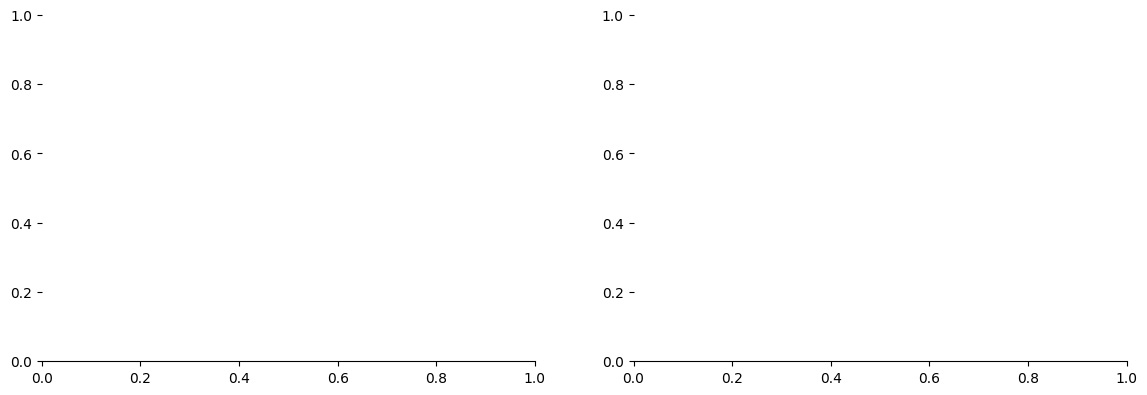

In [9]:
# Gràfic Elbow + Silhouette per visualitzar la decisió

# Paleta editorial (mateixa que el Cap. I)
COL_PRINCIPAL = "#1F3A5F"   # blau marí
COL_ACCENT = "#C45911"      # taronja terrós

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# --- Subgràfic 1: Elbow (WCSS) ---
axes[0].plot(results_df["K"], results_df["WCSS"],
             marker="o", markersize=8, linewidth=2,
             color=COL_PRINCIPAL, markerfacecolor=COL_PRINCIPAL,
             markeredgecolor="white", markeredgewidth=1.5)
axes[0].set_title("Mètode del colze (Elbow)", loc="left", fontweight="bold", color="#222")
axes[0].set_xlabel("Nombre de clústers (K)", color="#444")
axes[0].set_ylabel("WCSS (Within-Cluster Sum of Squares)", color="#444")
axes[0].tick_params(axis="both", colors="#444", length=0)
axes[0].yaxis.grid(True, color="#cccccc", linestyle="-", linewidth=0.5, alpha=0.6)
axes[0].xaxis.grid(False)
axes[0].set_axisbelow(True)
for spine in axes[0].spines.values():
    spine.set_color("#cccccc")
axes[0].set_xticks(results_df["K"])

# --- Subgràfic 2: Silhouette ---
axes[1].plot(results_df["K"], results_df["Silhouette"],
             marker="o", markersize=8, linewidth=2,
             color=COL_ACCENT, markerfacecolor=COL_ACCENT,
             markeredgecolor="white", markeredgewidth=1.5)
axes[1].set_title("Silhouette Score", loc="left", fontweight="bold", color="#222")
axes[1].set_xlabel("Nombre de clústers (K)", color="#444")
axes[1].set_ylabel("Silhouette mitjà", color="#444")
axes[1].tick_params(axis="both", colors="#444", length=0)
axes[1].yaxis.grid(True, color="#cccccc", linestyle="-", linewidth=0.5, alpha=0.6)
axes[1].xaxis.grid(False)
axes[1].set_axisbelow(True)
for spine in axes[1].spines.values():
    spine.set_color("#cccccc")
axes[1].set_xticks(results_df["K"])

plt.tight_layout()
plt.savefig("../outputs/fig_2_1_elbow_silhouette.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()

print("✓ Figura 2.1 guardada")

In [10]:
# ============================================================
# K-MEANS DEFINITIU AMB K = 4
# ============================================================
K_OPTIM = 4

# Entrenament definitiu
kmeans_final = KMeans(
    n_clusters=K_OPTIM,
    random_state=RANDOM_STATE,
    n_init=10,
    max_iter=300,
)

kmeans_final.fit(X)

# Afegim les etiquetes definitives al DataFrame
rfm["segment"] = kmeans_final.labels_

print(f"✓ K-means definitiu entrenat amb K={K_OPTIM}")
print(f"  Iteracions: {kmeans_final.n_iter_}")
print(f"  WCSS final: {kmeans_final.inertia_:.2f}")
print(f"\nDistribució de clients per segment:")
print(rfm["segment"].value_counts().sort_index())

✓ K-means definitiu entrenat amb K=4
  Iteracions: 11
  WCSS final: 820544.66

Distribució de clients per segment:
segment
0    164463
1    275763
2    429878
3    124216
Name: count, dtype: int64


In [11]:
# Caracterització profunda dels 4 segments
# Per cada segment: mida, percentatge, i estadístics R-F-M

# Mitjanes
perfil_mean = rfm.groupby("segment").agg(
    n_clients=("customer_id", "count"),
    recency_mean=("Recency", "mean"),
    frequency_mean=("Frequency", "mean"),
    monetary_mean=("Monetary", "mean"),
).round(2)

# Medianes (importants per distribucions asimètriques!)
perfil_median = rfm.groupby("segment").agg(
    recency_median=("Recency", "median"),
    frequency_median=("Frequency", "median"),
    monetary_median=("Monetary", "median"),
).round(2)

# Percentatge
perfil_mean["percentatge"] = (perfil_mean["n_clients"] / len(rfm) * 100).round(2)

# Combinem
perfil_complet = pd.concat([perfil_mean, perfil_median], axis=1)

# Reordenem columnes
perfil_complet = perfil_complet[[
    "n_clients", "percentatge",
    "recency_mean", "recency_median",
    "frequency_mean", "frequency_median",
    "monetary_mean", "monetary_median",
]]

print("Caracterització dels 4 segments:")
print("=" * 80)
print(perfil_complet)

Caracterització dels 4 segments:
         n_clients  percentatge  recency_mean  recency_median  frequency_mean  \
segment                                                                         
0           164463        16.54         17.10            16.0           10.12   
1           275763        27.73        101.53            83.0           16.90   
2           429878        43.23        191.63           183.0            3.39   
3           124216        12.49         28.84            18.0           57.30   

         frequency_median  monetary_mean  monetary_median  
segment                                                    
0                     8.0           0.27             0.23  
1                    15.0           0.45             0.40  
2                     3.0           0.09             0.08  
3                    47.0           1.71             1.35  


In [12]:
# Desviacions típiques per segment
# Ens diuen com de "compacte" és cada clúster

perfil_std = rfm.groupby("segment").agg(
    recency_std=("Recency", "std"),
    frequency_std=("Frequency", "std"),
    monetary_std=("Monetary", "std"),
).round(2)

print("Dispersió interna de cada segment (desviació típica):")
print("=" * 60)
print(perfil_std)

# Coeficient de variació (std / mean) - més interpretable
print("\nCoeficient de variació (std / mean × 100):")
print("=" * 60)
cv = pd.DataFrame({
    "CV_Recency": (perfil_std["recency_std"] / perfil_mean["recency_mean"] * 100).round(1),
    "CV_Frequency": (perfil_std["frequency_std"] / perfil_mean["frequency_mean"] * 100).round(1),
    "CV_Monetary": (perfil_std["monetary_std"] / perfil_mean["monetary_mean"] * 100).round(1),
})
print(cv)

Dispersió interna de cada segment (desviació típica):
         recency_std  frequency_std  monetary_std
segment                                          
0              11.24           6.90          0.18
1              67.98           7.86          0.22
2              95.40           2.09          0.07
3              32.66          36.83          1.20

Coeficient de variació (std / mean × 100):
         CV_Recency  CV_Frequency  CV_Monetary
segment                                       
0              65.7          68.2         66.7
1              67.0          46.5         48.9
2              49.8          61.7         77.8
3             113.2          64.3         70.2


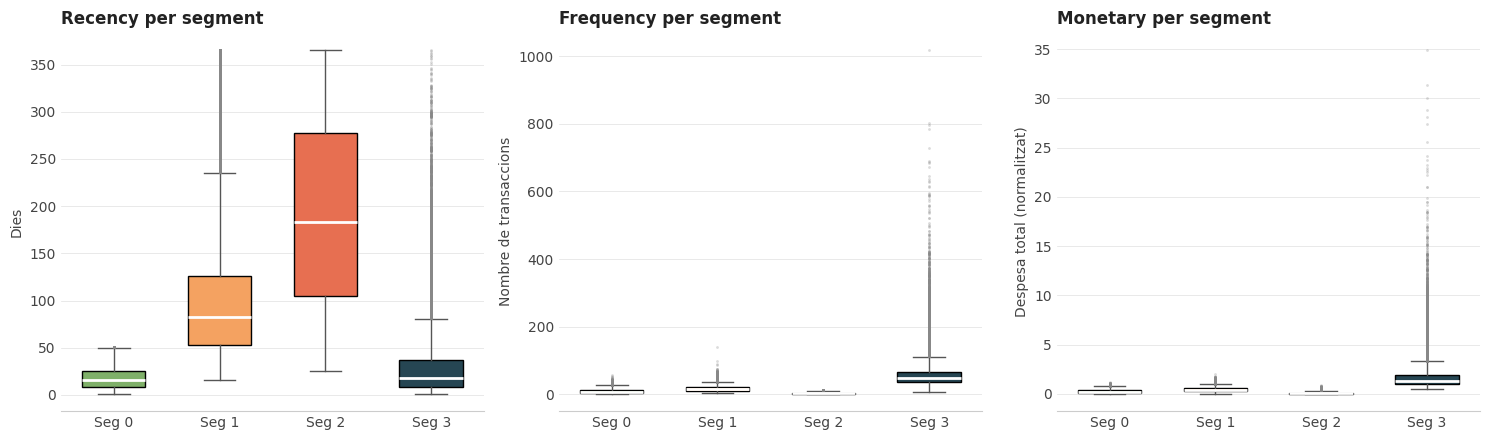

✓ Figura 2.2 guardada


In [13]:
# Boxplots de R, F, M per segment
# (Visualitza com es distribueix cada variable dins de cada segment)

# Paleta de colors per als 4 segments (estil editorial)
PALETA_SEGMENTS = ["#7FB069", "#F4A261", "#E76F51", "#264653"]
# Verd menta (S0), Taronja càlid (S1), Coral (S2), Blau marí fosc (S3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Recency
for i, seg in enumerate(sorted(rfm["segment"].unique())):
    data = rfm[rfm["segment"] == seg]["Recency"]
    bp = axes[0].boxplot(data, positions=[i], widths=0.6, patch_artist=True,
                         medianprops=dict(color="white", linewidth=2),
                         flierprops=dict(marker="o", markersize=2,
                                         markerfacecolor="#888", markeredgecolor="none", alpha=0.3),
                         whiskerprops=dict(color="#555"),
                         capprops=dict(color="#555"))
    bp["boxes"][0].set_facecolor(PALETA_SEGMENTS[seg])

axes[0].set_title("Recency per segment", loc="left", fontweight="bold", color="#222")
axes[0].set_xticks(range(4))
axes[0].set_xticklabels([f"Seg {i}" for i in range(4)])
axes[0].set_ylabel("Dies", color="#444")
axes[0].tick_params(axis="both", colors="#444", length=0)
axes[0].yaxis.grid(True, color="#cccccc", linestyle="-", linewidth=0.5, alpha=0.6)
axes[0].set_axisbelow(True)
for spine in axes[0].spines.values():
    spine.set_color("#cccccc")

# Frequency
for i, seg in enumerate(sorted(rfm["segment"].unique())):
    data = rfm[rfm["segment"] == seg]["Frequency"]
    bp = axes[1].boxplot(data, positions=[i], widths=0.6, patch_artist=True,
                         medianprops=dict(color="white", linewidth=2),
                         flierprops=dict(marker="o", markersize=2,
                                         markerfacecolor="#888", markeredgecolor="none", alpha=0.3),
                         whiskerprops=dict(color="#555"),
                         capprops=dict(color="#555"))
    bp["boxes"][0].set_facecolor(PALETA_SEGMENTS[seg])

axes[1].set_title("Frequency per segment", loc="left", fontweight="bold", color="#222")
axes[1].set_xticks(range(4))
axes[1].set_xticklabels([f"Seg {i}" for i in range(4)])
axes[1].set_ylabel("Nombre de transaccions", color="#444")
axes[1].tick_params(axis="both", colors="#444", length=0)
axes[1].yaxis.grid(True, color="#cccccc", linestyle="-", linewidth=0.5, alpha=0.6)
axes[1].set_axisbelow(True)
for spine in axes[1].spines.values():
    spine.set_color("#cccccc")

# Monetary
for i, seg in enumerate(sorted(rfm["segment"].unique())):
    data = rfm[rfm["segment"] == seg]["Monetary"]
    bp = axes[2].boxplot(data, positions=[i], widths=0.6, patch_artist=True,
                         medianprops=dict(color="white", linewidth=2),
                         flierprops=dict(marker="o", markersize=2,
                                         markerfacecolor="#888", markeredgecolor="none", alpha=0.3),
                         whiskerprops=dict(color="#555"),
                         capprops=dict(color="#555"))
    bp["boxes"][0].set_facecolor(PALETA_SEGMENTS[seg])

axes[2].set_title("Monetary per segment", loc="left", fontweight="bold", color="#222")
axes[2].set_xticks(range(4))
axes[2].set_xticklabels([f"Seg {i}" for i in range(4)])
axes[2].set_ylabel("Despesa total (normalitzat)", color="#444")
axes[2].tick_params(axis="both", colors="#444", length=0)
axes[2].yaxis.grid(True, color="#cccccc", linestyle="-", linewidth=0.5, alpha=0.6)
axes[2].set_axisbelow(True)
for spine in axes[2].spines.values():
    spine.set_color("#cccccc")

plt.tight_layout()
plt.savefig("../outputs/fig_2_2_boxplots_per_segment.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()

print("✓ Figura 2.2 guardada")

In [14]:
# ============================================================
# REDUCCIÓ DE DIMENSIONS AMB PCA PER VISUALITZACIÓ 2D
# ============================================================

# Apliquem PCA per reduir de 3D a 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

# Variància explicada per cada component
var_exp = pca.explained_variance_ratio_

print(f"Variància explicada per cada component principal:")
print(f"  PC1: {var_exp[0]:.4f}  ({var_exp[0]*100:.2f} %)")
print(f"  PC2: {var_exp[1]:.4f}  ({var_exp[1]*100:.2f} %)")
print(f"  Total: {var_exp.sum()*100:.2f} %")

# Components principals (interpretació de les direccions)
print(f"\nDirecció dels components principals (loadings):")
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=["Recency_z", "Frequency_z", "Monetary_z"]
)
print(loadings.round(3))

Variància explicada per cada component principal:
  PC1: 0.7478  (74.78 %)
  PC2: 0.2132  (21.32 %)
  Total: 96.10 %

Direcció dels components principals (loadings):
               PC1    PC2
Recency_z   -0.475  0.879
Frequency_z  0.627  0.303
Monetary_z   0.618  0.368


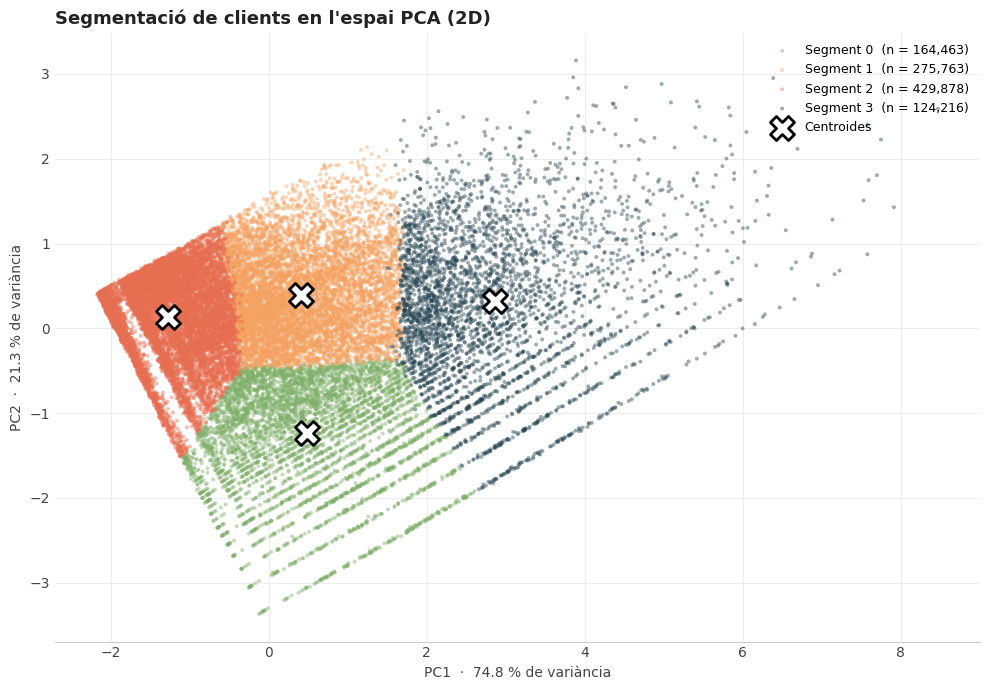

✓ Figura 2.3 guardada


In [15]:
# Gràfic dispersió 2D amb els 4 segments
# Fem submostra perquè 994k punts saturarien el gràfic

np.random.seed(RANDOM_STATE)
idx_plot = np.random.choice(len(X), size=30000, replace=False)
X_plot = X_pca[idx_plot]
seg_plot = rfm["segment"].values[idx_plot]

# Mateix paleta que als boxplots
PALETA_SEGMENTS = ["#7FB069", "#F4A261", "#E76F51", "#264653"]

fig, ax = plt.subplots(figsize=(10, 7))

# Dibuixem cada segment per separat per poder posar llegenda
for seg in sorted(rfm["segment"].unique()):
    mask = seg_plot == seg
    ax.scatter(
        X_plot[mask, 0], X_plot[mask, 1],
        s=8, alpha=0.45,
        c=PALETA_SEGMENTS[seg],
        edgecolors="none",
        label=f"Segment {seg}  (n = {(rfm['segment']==seg).sum():,})",
    )

# Centroides projectats al PCA
centroides_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(
    centroides_pca[:, 0], centroides_pca[:, 1],
    s=300, marker="X",
    c="white", edgecolors="black", linewidths=2,
    zorder=5, label="Centroides",
)

ax.set_title("Segmentació de clients en l'espai PCA (2D)",
             loc="left", fontweight="bold", color="#222", fontsize=13)
ax.set_xlabel(f"PC1  ·  {var_exp[0]*100:.1f} % de variància", color="#444")
ax.set_ylabel(f"PC2  ·  {var_exp[1]*100:.1f} % de variància", color="#444")
ax.tick_params(axis="both", colors="#444", length=0)
ax.grid(True, color="#cccccc", linestyle="-", linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color("#cccccc")
ax.legend(loc="upper right", frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/fig_2_3_pca_segments.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()

print("✓ Figura 2.3 guardada")

In [16]:
# Assignem noms descriptius als 4 segments
SEGMENT_NAMES = {
    0: "Compradors Recents",
    1: "En Risc",
    2: "Hibernants",
    3: "Champions",
}

# Afegim columna amb el nom
rfm["segment_nom"] = rfm["segment"].map(SEGMENT_NAMES)

# Verifiquem
print("Distribució amb noms:")
print(rfm["segment_nom"].value_counts())
print(f"\nPercentatge:")
print((rfm["segment_nom"].value_counts(normalize=True) * 100).round(2))

Distribució amb noms:
segment_nom
Hibernants            429878
En Risc               275763
Compradors Recents    164463
Champions             124216
Name: count, dtype: int64

Percentatge:
segment_nom
Hibernants            43.23
En Risc               27.73
Compradors Recents    16.54
Champions             12.49
Name: proportion, dtype: float64


In [17]:
# Taula resum final amb noms
taula_final = rfm.groupby("segment_nom").agg(
    N_clients=("customer_id", "count"),
    Percentatge=("customer_id", lambda x: round(len(x)/len(rfm)*100, 1)),
    Recency_mediana=("Recency", "median"),
    Frequency_mediana=("Frequency", "median"),
    Monetary_mediana=("Monetary", "median"),
).round(2)

# Reordenem per a una lectura natural (Champions a dalt, Hibernants a baix)
ordre = ["Champions", "En Risc", "Compradors Recents", "Hibernants"]
taula_final = taula_final.reindex(ordre)

print("=" * 65)
print("TAULA RESUM FINAL — Caracterització dels 4 segments")
print("=" * 65)
print(taula_final)

TAULA RESUM FINAL — Caracterització dels 4 segments
                    N_clients  Percentatge  Recency_mediana  \
segment_nom                                                   
Champions              124216         12.5             18.0   
En Risc                275763         27.7             83.0   
Compradors Recents     164463         16.5             16.0   
Hibernants             429878         43.2            183.0   

                    Frequency_mediana  Monetary_mediana  
segment_nom                                              
Champions                        47.0              1.35  
En Risc                          15.0              0.40  
Compradors Recents                8.0              0.23  
Hibernants                        3.0              0.08  


In [18]:
# Guardem el DataFrame final amb segments
rfm.to_parquet("../outputs/rfm_segments.parquet", index=False)
rfm.to_csv("../outputs/rfm_segments.csv", index=False)

# També guardem el model K-means entrenat (per reutilitzar-lo)
import joblib
joblib.dump(kmeans_final, "../outputs/kmeans_model.joblib")
joblib.dump(pca, "../outputs/pca_model.joblib")

print(f"✓ rfm_segments.parquet i .csv guardats")
print(f"✓ Models K-means i PCA serialitzats")
print(f"\nTotal de clients amb segment assignat: {len(rfm):,}")
print(f"Total de variables finals: {len(rfm.columns)} columnes")

✓ rfm_segments.parquet i .csv guardats
✓ Models K-means i PCA serialitzats

Total de clients amb segment assignat: 994,320
Total de variables finals: 13 columnes


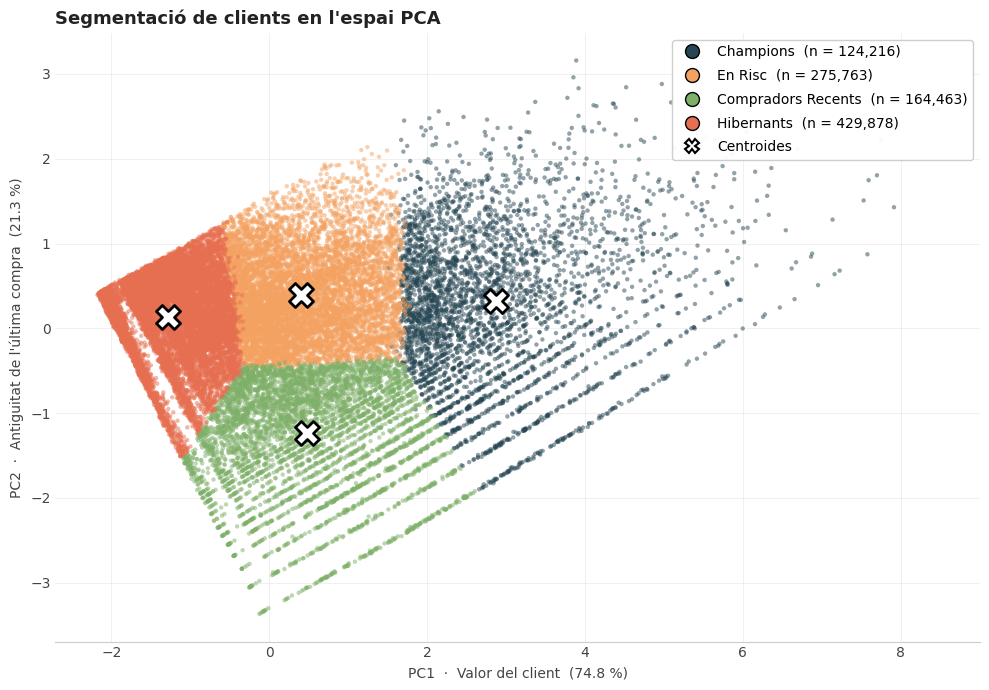

✓ Figura 2.4 (versió millorada) guardada


In [19]:
# ============================================================
# FIGURA 2.4 — Versió millorada amb llegenda neta
# ============================================================

# Mateixa submostra
np.random.seed(RANDOM_STATE)
idx_plot = np.random.choice(len(X), size=30000, replace=False)
X_plot = X_pca[idx_plot]
seg_plot = rfm["segment"].values[idx_plot]

# Paleta editorial
PALETA_SEGMENTS = ["#7FB069", "#F4A261", "#E76F51", "#264653"]

# Noms per a la llegenda (en ordre d'importància)
NOMS_LLEGENDA = {
    0: "Compradors Recents",
    1: "En Risc",
    2: "Hibernants",
    3: "Champions",
}

# Ordre desitjat a la llegenda (de més a menys valor)
ORDRE = [3, 1, 0, 2]

fig, ax = plt.subplots(figsize=(10, 7))

# Dibuixem cada segment (en ordre estètic, no d'index)
handles_dict = {}
for seg in ORDRE:
    mask = seg_plot == seg
    n_seg = (rfm['segment'] == seg).sum()
    sc = ax.scatter(
        X_plot[mask, 0], X_plot[mask, 1],
        s=10, alpha=0.5,
        c=PALETA_SEGMENTS[seg],
        edgecolors="none",
    )
    handles_dict[seg] = sc

# Centroides
centroides_pca = pca.transform(kmeans_final.cluster_centers_)
sc_cent = ax.scatter(
    centroides_pca[:, 0], centroides_pca[:, 1],
    s=300, marker="X",
    c="white", edgecolors="black", linewidths=2,
    zorder=5,
)

# LLEGENDA MANUAL amb mida controlada
from matplotlib.lines import Line2D
legend_elements = []
for seg in ORDRE:
    n_seg = (rfm['segment'] == seg).sum()
    legend_elements.append(
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=PALETA_SEGMENTS[seg],
               markersize=10,  # ← mida controlada del punt a la llegenda
               label=f"{NOMS_LLEGENDA[seg]}  (n = {n_seg:,})")
    )
# Centroides a part
legend_elements.append(
    Line2D([0], [0], marker="X", color="none",
           markerfacecolor="white", markeredgecolor="black", markersize=10,
           markeredgewidth=1.5, label="Centroides")
)

ax.legend(handles=legend_elements, loc="upper right",
          frameon=True, framealpha=0.95, edgecolor="#cccccc",
          fontsize=10, labelspacing=0.7)

# Estètica
ax.set_title("Segmentació de clients en l'espai PCA",
             loc="left", fontweight="bold", color="#222", fontsize=13)
ax.set_xlabel(f"PC1  ·  Valor del client  ({var_exp[0]*100:.1f} %)", color="#444")
ax.set_ylabel(f"PC2  ·  Antiguitat de l'última compra  ({var_exp[1]*100:.1f} %)", color="#444")
ax.tick_params(axis="both", colors="#444", length=0)
ax.grid(True, color="#cccccc", linestyle="-", linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color("#cccccc")

plt.tight_layout()
plt.savefig("../outputs/fig_2_4_pca_segments_noms.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()

print("✓ Figura 2.4 (versió millorada) guardada")

Columnes disponibles: ['customer_id', 'Recency', 'Frequency', 'Monetary', 'Recency_log', 'Frequency_log', 'Monetary_log', 'Recency_z', 'Frequency_z', 'Monetary_z', 'cluster_K4', 'segment', 'segment_nom']

Columna de segments detectada: 'segment'
Submostra: 20000 clients

Calculant silhouette scores...
Silhouette mitjana global: 0.3560



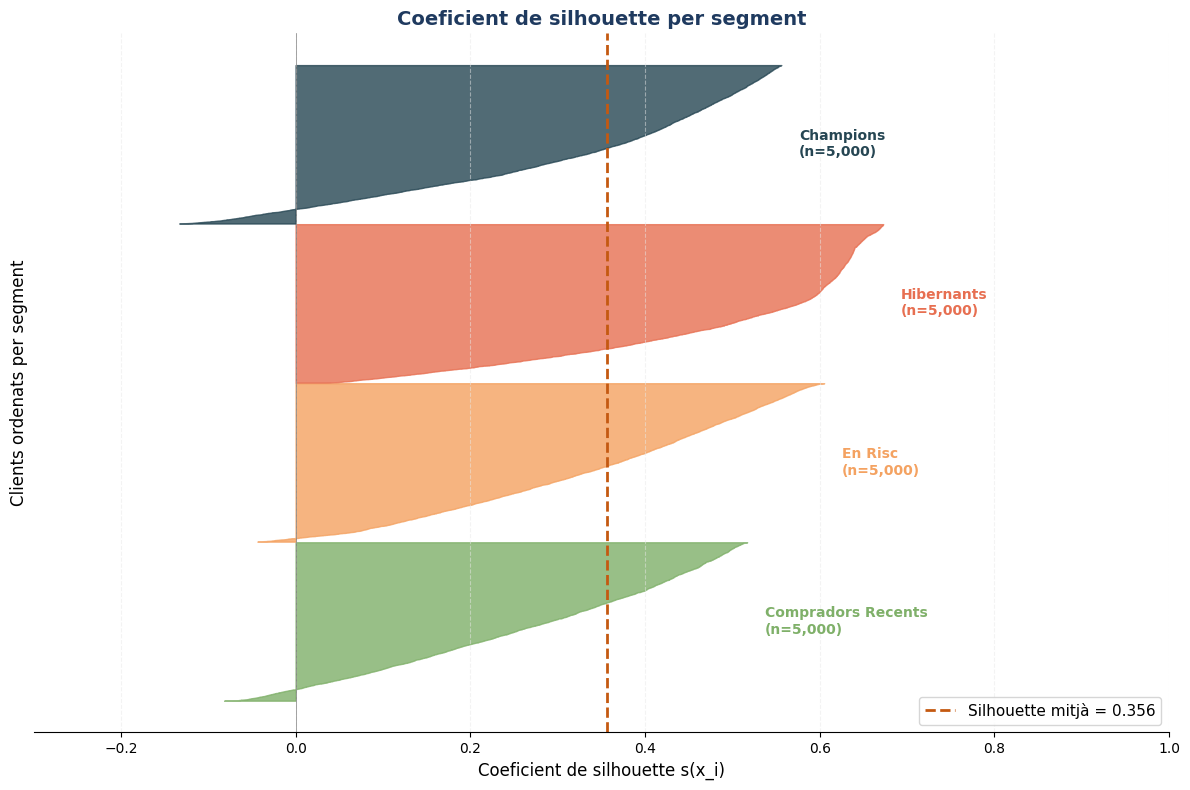


✅ Figura generada: outputs/fig_2_X_silhouette_per_segment.png
   Silhouette mitjà global: 0.3560


In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans

# Crear la carpeta outputs si no existeix
os.makedirs('outputs', exist_ok=True)

# ============================================
# CONFIGURACIÓ (paleta segments)
# ============================================
SEGMENT_COLORS = {
    0: "#7FB069",  # verd menta (Compradors Recents)
    1: "#F4A261",  # taronja càlid (En Risc)
    2: "#E76F51",  # coral (Hibernants)
    3: "#264653",  # blau marí (Champions)
}
SEGMENT_NAMES = {
    0: "Compradors Recents",
    1: "En Risc",
    2: "Hibernants",
    3: "Champions",
}

# ============================================
# PREPARACIÓ DE LES DADES
# ============================================
# Detectar el DataFrame i les columnes
print(f"Columnes disponibles: {rfm.columns.tolist()}\n")

# Verificar que tenim les variables transformades
if 'Recency_z' not in rfm.columns:
    print("⚠️  Calculant transformacions...")
    from sklearn.preprocessing import StandardScaler
    rfm['Recency_log'] = np.log1p(rfm['Recency'])
    rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
    rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
    scaler = StandardScaler()
    rfm[['Recency_z', 'Frequency_z', 'Monetary_z']] = scaler.fit_transform(
        rfm[['Recency_log', 'Frequency_log', 'Monetary_log']]
    )

X_z = rfm[['Recency_z', 'Frequency_z', 'Monetary_z']].values

# Detectar la columna del clúster (pot tenir noms diferents)
cluster_col = None
for candidate in ['Segment', 'cluster', 'kmeans_label', 'label', 'segment']:
    if candidate in rfm.columns:
        cluster_col = candidate
        break

if cluster_col is None:
    print("⚠️  Re-executant K-means amb K=4...")
    kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
    rfm['Segment'] = kmeans.fit_predict(X_z)
    cluster_col = 'Segment'

print(f"Columna de segments detectada: '{cluster_col}'")

# ============================================
# SUBMOSTREIG ESTRATIFICAT
# ============================================
# Per evitar saturar la figura, prenem una mostra estratificada
np.random.seed(42)
sample_size_per_cluster = 5000

idx_samples = []
for seg in [0, 1, 2, 3]:
    seg_idx = rfm.index[rfm[cluster_col] == seg].tolist()
    chosen = np.random.choice(seg_idx, 
                              size=min(sample_size_per_cluster, len(seg_idx)),
                              replace=False)
    idx_samples.extend(chosen)

X_sample = X_z[idx_samples]
labels_sample = rfm.loc[idx_samples, cluster_col].values

print(f"Submostra: {len(idx_samples)} clients")

# ============================================
# CÀLCUL DEL SILHOUETTE
# ============================================
print(f"\nCalculant silhouette scores...")
silhouette_vals = silhouette_samples(X_sample, labels_sample)
silhouette_avg = silhouette_score(X_sample, labels_sample)

print(f"Silhouette mitjana global: {silhouette_avg:.4f}\n")

# ============================================
# GENERACIÓ DEL GRÀFIC
# ============================================
fig, ax = plt.subplots(figsize=(12, 8))

y_lower = 10
for seg in sorted(np.unique(labels_sample)):
    seg_silhouette_vals = silhouette_vals[labels_sample == seg]
    seg_silhouette_vals.sort()
    
    size_cluster = len(seg_silhouette_vals)
    y_upper = y_lower + size_cluster
    
    color = SEGMENT_COLORS[seg]
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, seg_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.8)
    
    # Etiqueta de cada clúster a la dreta
    ax.text(seg_silhouette_vals.max() + 0.02, 
            y_lower + 0.5 * size_cluster,
            f"{SEGMENT_NAMES[seg]}\n(n={size_cluster:,})",
            fontsize=10, color=color, fontweight='bold',
            verticalalignment='center')
    
    y_lower = y_upper + 20

# Línia vertical amb el silhouette mitjà
ax.axvline(x=silhouette_avg, color="#C45911", linestyle="--", linewidth=2,
           label=f'Silhouette mitjà = {silhouette_avg:.3f}')

ax.set_title("Coeficient de silhouette per segment",
             fontsize=14, fontweight='bold', color="#1F3A5F")
ax.set_xlabel("Coeficient de silhouette s(x_i)", fontsize=12)
ax.set_ylabel("Clients ordenats per segment", fontsize=12)
ax.set_yticks([])
ax.set_xlim([-0.3, 1.0])
ax.legend(loc='lower right', fontsize=11)
ax.set_facecolor('white')
ax.grid(axis='x', linestyle='--', alpha=0.5, color='#E8E8E8')

# Línia vertical a 0 (frontera)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('outputs/fig_2_X_silhouette_per_segment.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Figura generada: outputs/fig_2_X_silhouette_per_segment.png")
print(f"   Silhouette mitjà global: {silhouette_avg:.4f}")